In [12]:
!npm install -g @mermaid-js/mermaid-cli

'npm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [13]:
# =========================
# CONFIG
# =========================
SRC_FILE = "text2sql_langgraph.py"
OUT_DIR = Path("vis")


# =========================
# IMPORT
# =========================
import ast
import subprocess
from pathlib import Path
from IPython.display import SVG, display


# =========================
# AST EXTRACTOR
# =========================
class Extractor(ast.NodeVisitor):
    def __init__(self):
        self.nodes = {}
        self.edges = []
        self.conds = []

    def _get_name(self, node):
        if isinstance(node, ast.Constant):
            return node.value
        elif isinstance(node, ast.Name):
            return node.id
        else:
            try:
                return ast.unparse(node)
            except:
                return str(node)

    def visit_Call(self, node):
        if isinstance(node.func, ast.Attribute):

            if node.func.attr == "add_node":
                n = self._get_name(node.args[0])
                f = self._get_name(node.args[1])
                self.nodes[n] = f

            elif node.func.attr == "add_edge":
                s = self._get_name(node.args[0])
                d = self._get_name(node.args[1])
                self.edges.append((s, d))

            elif node.func.attr == "add_conditional_edges":
                src = self._get_name(node.args[0])
                mapping = {}
                for k, v in zip(node.args[2].keys, node.args[2].values):
                    mapping[self._get_name(k)] = self._get_name(v)
                self.conds.append((src, mapping))

        self.generic_visit(node)


# =========================
# STATE EXTRACTOR
# =========================
class StateExtractor(ast.NodeVisitor):
    def __init__(self):
        self.fields = []

    def visit_ClassDef(self, node):
        if node.name == "AgentState":
            for stmt in node.body:
                if isinstance(stmt, ast.AnnAssign):
                    self.fields.append(stmt.target.id)


# =========================
# BUILD MERMAID
# =========================
def build_mermaid(ext):
    lines = ["flowchart TD"]

    for n in ext.nodes:
        lines.append(f'    {n}["{n}"]')

    lines.append("")

    for s, d in ext.edges:
        lines.append(f"    {s} --> {d}")

    for s, mapping in ext.conds:
        for cond, d in mapping.items():
            lines.append(f'    {s} -->|"{cond}"| {d}')

    return "\n".join(lines)


# =========================
# RUN ANALYSIS
# =========================
OUT_DIR.mkdir(exist_ok=True)

code = Path(SRC_FILE).read_text(encoding="utf-8")
tree = ast.parse(code)

ext = Extractor()
ext.visit(tree)

state_ext = StateExtractor()
state_ext.visit(tree)


# =========================
# SAVE FILES (vis/)
# =========================

# Mermaid
mermaid = build_mermaid(ext)
(Path(OUT_DIR / "workflow.mmd")).write_text(mermaid, encoding="utf-8")

# State map
state_lines = ["# State Fields\n"]
for f in state_ext.fields:
    state_lines.append(f"- {f}")
(Path(OUT_DIR / "state_field_map.md")).write_text("\n".join(state_lines), encoding="utf-8")

# Routes debug
routes_lines = ["# Routes\n"]
for src, mapping in ext.conds:
    routes_lines.append(f"\n## {src}")
    for k, v in mapping.items():
        routes_lines.append(f"- {k} -> {v}")
(Path(OUT_DIR / "routes_debug.md")).write_text("\n".join(routes_lines), encoding="utf-8")

# Nodes debug
nodes_lines = ["# Nodes\n"]
for n, f in ext.nodes.items():
    nodes_lines.append(f"- {n} -> {f}")
(Path(OUT_DIR / "nodes_debug.md")).write_text("\n".join(nodes_lines), encoding="utf-8")

print("✅ vis/ 폴더에 mmd + md 생성 완료")


# =========================
# SVG 생성 (vis/)
# =========================
try:
    subprocess.run([
        "mmdc",
        "-i", str(OUT_DIR / "workflow.mmd"),
        "-o", str(OUT_DIR / "workflow.svg")
    ])

    print("✅ SVG 생성 완료")

    display(SVG(str(OUT_DIR / "workflow.svg")))

except Exception as e:
    print("⚠️ mmdc 없음 → SVG 생성 스킵")
    print("설치: npm install -g @mermaid-js/mermaid-cli")

✅ vis/ 폴더에 mmd + md 생성 완료
⚠️ mmdc 없음 → SVG 생성 스킵
설치: npm install -g @mermaid-js/mermaid-cli


status: 200


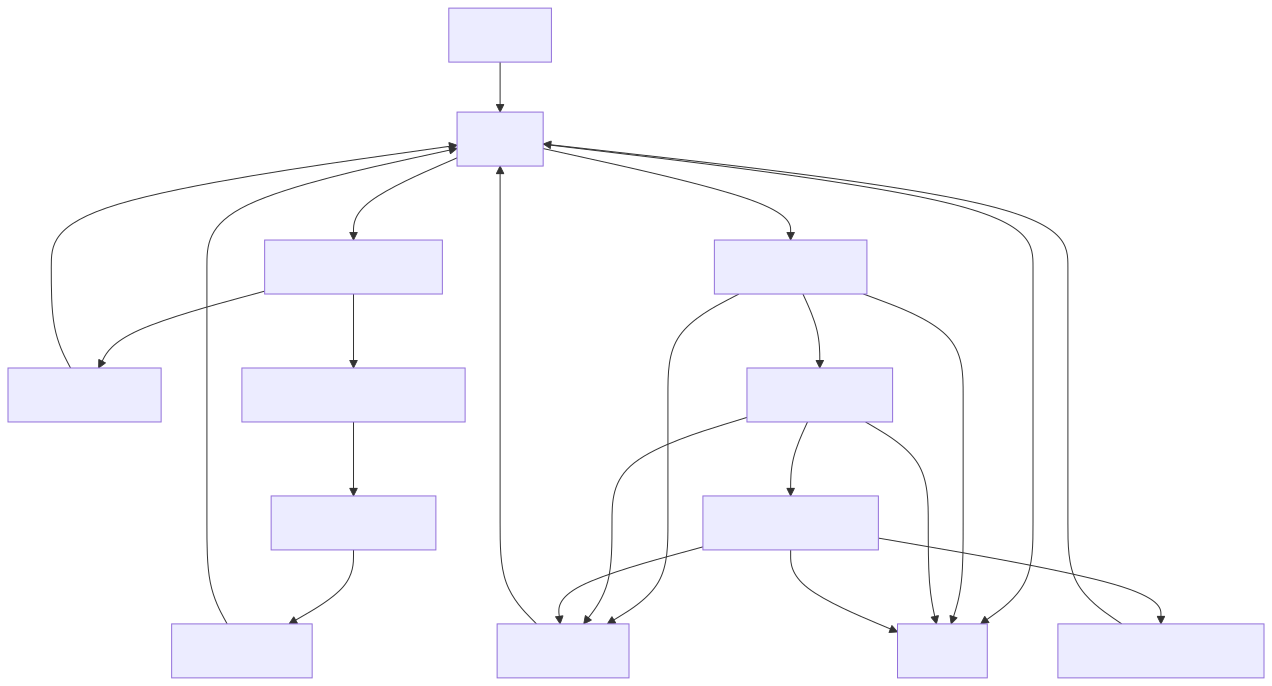

In [20]:
from pathlib import Path
from IPython.display import SVG, display
import requests

mmd_path = Path("vis/workflow.mmd")
svg_path = Path("vis/workflow.svg")

mmd = mmd_path.read_text(encoding="utf-8")

url = "https://kroki.io/mermaid/svg"
resp = requests.post(
    url,
    data=mmd.encode("utf-8"),
    headers={"Content-Type": "text/plain"},
    timeout=30,
)

print("status:", resp.status_code)

if resp.status_code != 200:
    print(resp.text[:1000])
    raise RuntimeError("Kroki 렌더링 실패")

svg_path.write_bytes(resp.content)
display(SVG(filename=str(svg_path)))

생성 완료:
- vis\workflow_raw.mmd
- vis\workflow_clean.mmd
- vis\state_field_map.md
- vis\routes_debug.md
- vis\workflow_clean.svg


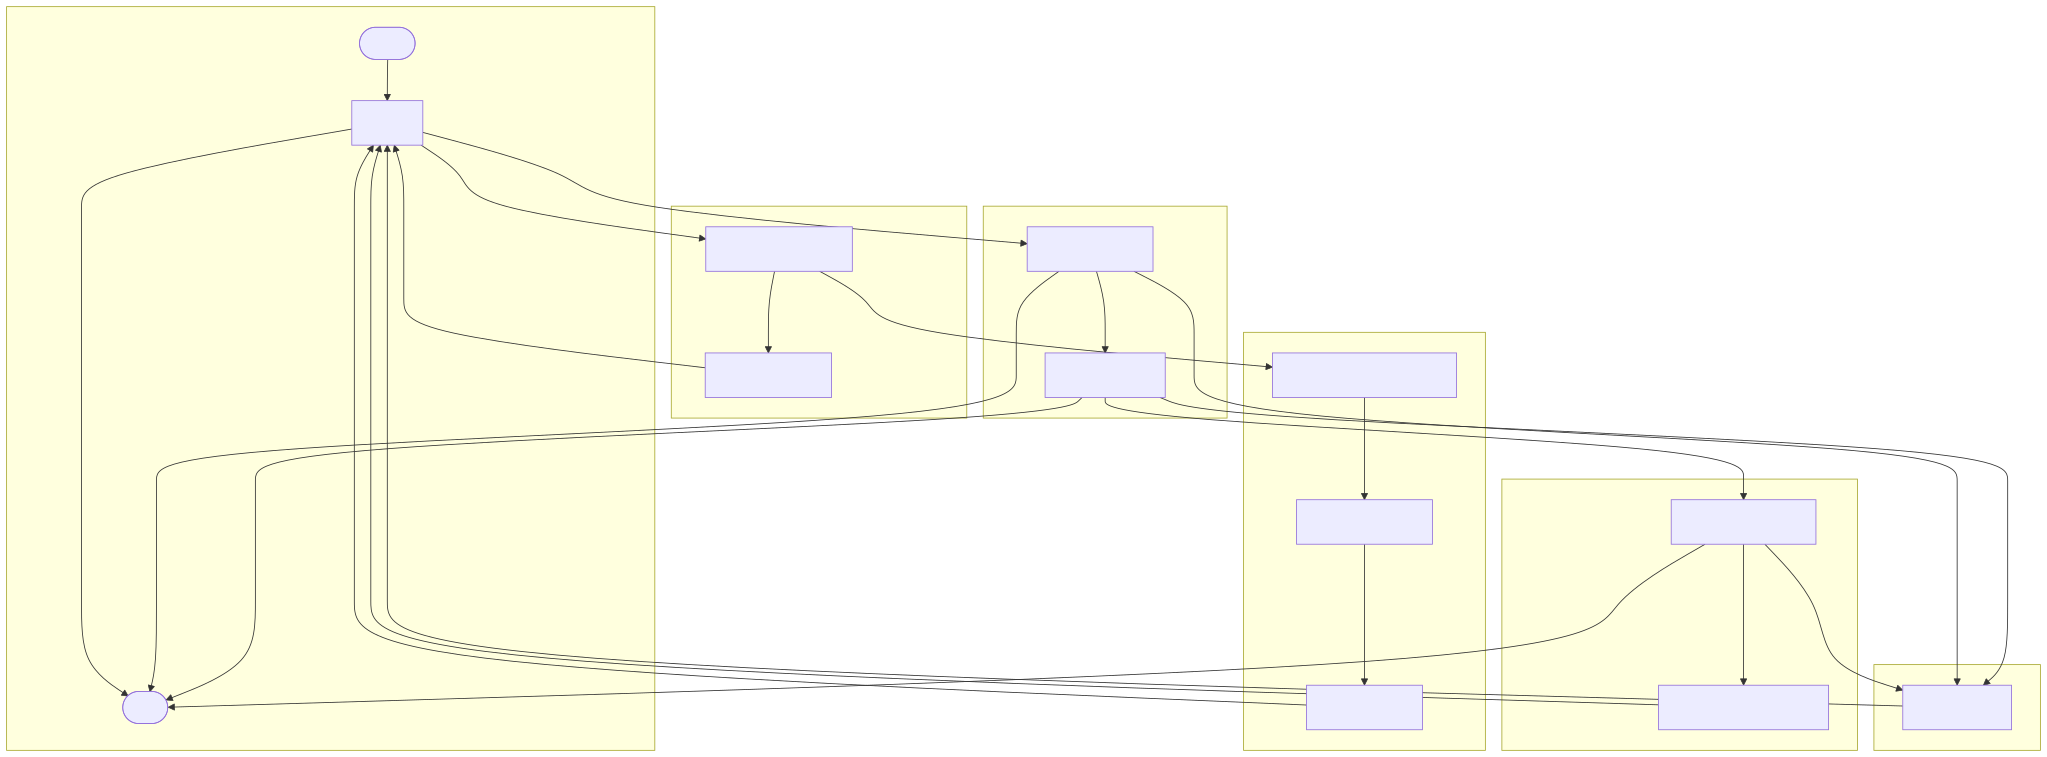

In [22]:
# =========================
# CONFIG
# =========================
SRC_FILE = "text2sql_langgraph.py"
OUT_DIR = "vis"


# =========================
# IMPORT
# =========================
import ast
import re
from pathlib import Path
from collections import defaultdict
from IPython.display import SVG, display
import requests


# =========================
# HELPERS
# =========================
def node_to_str(node):
    if isinstance(node, ast.Constant):
        return str(node.value)
    if isinstance(node, ast.Name):
        return node.id
    try:
        return ast.unparse(node)
    except Exception:
        return str(node)

def safe_label(s: str) -> str:
    return s.replace('"', "'")

def pretty_route_label(label: str) -> str:
    s = str(label)

    replacements = {
        "prepare_context": "prepare context",
        "safety_check": "go to safety check",
        "repair_sql": "repair",
        "semantic_check": "semantic check",
        "semantic_repair_sql": "semantic repair",
        "generate_sql": "generate",
        "rewrite_sql": "rewrite",
        "END": "end",
    }
    if s in replacements:
        return replacements[s]
    return s.replace("_", " ")

def classify_node(name: str) -> str:
    n = name.lower()
    if n in {"start", "end", "tick"}:
        return "control"
    if "rewrite" in n:
        return "rewrite"
    if "semantic" in n:
        return "semantic"
    if "repair" in n:
        return "repair"
    if "execute" in n or "safety" in n:
        return "execution"
    if "prepare" in n or "generate" in n or "classify" in n:
        return "generation"
    return "other"

def extract_return_key(node):
    if isinstance(node, ast.Return) and node.value is not None:
        if isinstance(node.value, ast.Constant):
            return str(node.value.value)
        if isinstance(node.value, ast.Name):
            return node.value.id
    return None


# =========================
# EXTRACT GRAPH
# =========================
class GraphExtractor(ast.NodeVisitor):
    def __init__(self):
        self.nodes = {}              # graph_node_name -> function_name
        self.edges = []              # (src, dst)
        self.cond_edges = []         # (src, route_fn, mapping_dict)
        self.route_fns = {}          # route_fn_name -> FunctionDef
        self.node_fns = {}           # function_name -> FunctionDef
        self.agent_state_fields = []

    def visit_ClassDef(self, node):
        if node.name == "AgentState":
            for stmt in node.body:
                if isinstance(stmt, ast.AnnAssign) and isinstance(stmt.target, ast.Name):
                    self.agent_state_fields.append(stmt.target.id)
        self.generic_visit(node)

    def visit_FunctionDef(self, node):
        if node.name.startswith("route_after_"):
            self.route_fns[node.name] = node
        if node.name.startswith("node_"):
            self.node_fns[node.name] = node
        self.generic_visit(node)

    def visit_Call(self, node):
        if isinstance(node.func, ast.Attribute):
            attr = node.func.attr

            if attr == "add_node" and len(node.args) >= 2:
                graph_node = node_to_str(node.args[0])
                fn_name = node_to_str(node.args[1])
                self.nodes[graph_node] = fn_name

            elif attr == "add_edge" and len(node.args) >= 2:
                src = node_to_str(node.args[0])
                dst = node_to_str(node.args[1])
                self.edges.append((src, dst))

            elif attr == "add_conditional_edges" and len(node.args) >= 3:
                src = node_to_str(node.args[0])
                route_fn = node_to_str(node.args[1])
                mapping = {}
                if isinstance(node.args[2], ast.Dict):
                    for k, v in zip(node.args[2].keys, node.args[2].values):
                        mapping[node_to_str(k)] = node_to_str(v)
                self.cond_edges.append((src, route_fn, mapping))

        self.generic_visit(node)


# =========================
# ROUTE ANALYSIS
# =========================
class RouteAnalyzer:
    def __init__(self, route_fn: ast.FunctionDef):
        self.route_fn = route_fn
        self.labels = defaultdict(list)   # return_key -> [label1, label2, ...]

    def analyze(self):
        self._walk(self.route_fn.body, active_cond=None)
        return dict(self.labels)

    def _cond_to_text(self, expr):
        try:
            s = ast.unparse(expr)
        except Exception:
            s = str(expr)

        s = s.replace("state.get(", "").replace(")", "")
        s = s.replace("cfg.", "")
        s = s.replace("state[", "").replace("]", "")
        s = s.replace('"', "").replace("'", "")
        s = s.replace("_", " ")
        s = re.sub(r"\s+", " ", s).strip()

        # 흔한 패턴 정리
        s = s.replace("error and Step limit exceeded in error", "step limit exceeded")
        s = s.replace("error", "error")
        s = s.replace("semantic error", "semantic error")
        s = s.replace("enable semantic check", "semantic check enabled")
        s = s.replace("attempts >= max repair attempts", "attempt limit reached")
        s = s.replace("not schema", "schema missing")

        return s

    def _merge_cond(self, a, b):
        if a and b:
            return f"{a} AND {b}"
        return a or b or "otherwise"

    def _walk(self, stmts, active_cond=None):
        for stmt in stmts:
            if isinstance(stmt, ast.If):
                cond = self._cond_to_text(stmt.test)
                self._walk(stmt.body, self._merge_cond(active_cond, cond))
                if stmt.orelse:
                    self._walk(stmt.orelse, self._merge_cond(active_cond, f"NOT ({cond})"))

            elif isinstance(stmt, ast.Return):
                key = extract_return_key(stmt)
                if key is not None:
                    self.labels[key].append(active_cond or "otherwise")


# =========================
# STATE READ/WRITE ANALYSIS
# =========================
class NodeStateAnalyzer(ast.NodeVisitor):
    def __init__(self, valid_fields):
        self.valid_fields = set(valid_fields)
        self.reads = set()
        self.writes = set()

    def visit_Call(self, node):
        # state.get("x")
        if (
            isinstance(node.func, ast.Attribute)
            and node.func.attr == "get"
            and isinstance(node.func.value, ast.Name)
            and node.func.value.id == "state"
            and len(node.args) >= 1
            and isinstance(node.args[0], ast.Constant)
            and isinstance(node.args[0].value, str)
        ):
            k = node.args[0].value
            if k in self.valid_fields:
                self.reads.add(k)
        self.generic_visit(node)

    def visit_Subscript(self, node):
        # state["x"]
        if (
            isinstance(node.value, ast.Name)
            and node.value.id == "state"
            and isinstance(node.slice, ast.Constant)
            and isinstance(node.slice.value, str)
        ):
            k = node.slice.value
            if k in self.valid_fields:
                self.reads.add(k)
        self.generic_visit(node)

    def visit_Return(self, node):
        # return {"sql": ..., "error": ...}
        if isinstance(node.value, ast.Dict):
            for k in node.value.keys:
                if isinstance(k, ast.Constant) and isinstance(k.value, str):
                    if k.value in self.valid_fields:
                        self.writes.add(k.value)
        self.generic_visit(node)


# =========================
# RENDER RAW MERMAID
# =========================
def render_raw_mermaid(ext: GraphExtractor, route_labels_map):
    lines = ["flowchart TD"]

    all_nodes = set(ext.nodes.keys())
    for s, d in ext.edges:
        all_nodes.add(s)
        all_nodes.add(d)
    for s, _, mp in ext.cond_edges:
        all_nodes.add(s)
        for d in mp.values():
            all_nodes.add(d)

    for n in sorted(all_nodes):
        if n == "START":
            lines.append(f'    {n}(["START"])')
        elif n == "END":
            lines.append(f'    {n}(["END"])')
        else:
            lines.append(f'    {n}["{safe_label(n)}"]')

    lines.append("")

    for s, d in ext.edges:
        lines.append(f"    {s} --> {d}")

    for s, route_fn, mp in ext.cond_edges:
        label_map = route_labels_map.get(route_fn, {})
        for ret_key, dst in mp.items():
            labels = label_map.get(ret_key, [pretty_route_label(ret_key)])
            label = " OR ".join(labels)
            label = safe_label(label)
            lines.append(f'    {s} -->|"{label}"| {dst}')

    return "\n".join(lines)


# =========================
# RENDER CLEAN MERMAID
# =========================
def render_clean_mermaid(ext: GraphExtractor, route_labels_map):
    all_nodes = set(ext.nodes.keys())
    for s, d in ext.edges:
        all_nodes.add(s); all_nodes.add(d)
    for s, _, mp in ext.cond_edges:
        all_nodes.add(s)
        for d in mp.values():
            all_nodes.add(d)

    groups = defaultdict(list)
    for n in sorted(all_nodes):
        groups[classify_node(n)].append(n)

    ordered_groups = ["control", "generation", "rewrite", "execution", "repair", "semantic", "other"]

    lines = ["flowchart TD"]

    # subgraphs
    for g in ordered_groups:
        if not groups[g]:
            continue
        lines.append(f"    subgraph {g.upper()}")
        for n in groups[g]:
            if n == "START":
                lines.append(f'        {n}(["START"])')
            elif n == "END":
                lines.append(f'        {n}(["END"])')
            else:
                lines.append(f'        {n}["{safe_label(n)}"]')
        lines.append("    end")
        lines.append("")

    # normal edges
    for s, d in ext.edges:
        lines.append(f"    {s} --> {d}")

    # conditional edges
    for s, route_fn, mp in ext.cond_edges:
        label_map = route_labels_map.get(route_fn, {})
        for ret_key, dst in mp.items():
            labels = label_map.get(ret_key, [pretty_route_label(ret_key)])
            label = " OR ".join(labels)
            label = safe_label(label)
            lines.append(f'    {s} -->|"{label}"| {dst}')

    return "\n".join(lines)


# =========================
# RENDER STATE MAP
# =========================
def render_state_field_map(ext: GraphExtractor):
    lines = ["# State Field Map", "", "## AgentState fields", ""]
    for f in ext.agent_state_fields:
        lines.append(f"- `{f}`")

    lines += ["", "## Node read/write map", "", "| node | function | reads | writes |", "|---|---|---|---|"]

    for node_name, fn_name in sorted(ext.nodes.items()):
        fn = ext.node_fns.get(fn_name)
        if fn is None:
            reads = ""
            writes = ""
        else:
            analyzer = NodeStateAnalyzer(ext.agent_state_fields)
            analyzer.visit(fn)
            reads = ", ".join(f"`{x}`" for x in sorted(analyzer.reads))
            writes = ", ".join(f"`{x}`" for x in sorted(analyzer.writes))
        lines.append(f"| `{node_name}` | `{fn_name}` | {reads} | {writes} |")

    return "\n".join(lines)


# =========================
# RENDER ROUTE DEBUG
# =========================
def render_route_debug(route_labels_map):
    lines = ["# Route Debug", ""]
    for route_fn, mp in sorted(route_labels_map.items()):
        lines.append(f"## `{route_fn}`")
        lines.append("")
        for ret_key, labels in mp.items():
            lines.append(f"- `{ret_key}`")
            for lb in labels:
                lines.append(f"  - {lb}")
        lines.append("")
    return "\n".join(lines)


# =========================
# KROKI RENDER
# =========================
def kroki_render_mermaid_to_svg(mmd_text: str, out_path: Path):
    resp = requests.post(
        "https://kroki.io/mermaid/svg",
        data=mmd_text.encode("utf-8"),
        headers={"Content-Type": "text/plain"},
        timeout=60,
    )
    if resp.status_code != 200:
        raise RuntimeError(f"Kroki render failed: {resp.status_code}\n{resp.text[:1000]}")
    out_path.write_bytes(resp.content)


# =========================
# RUN
# =========================
src_path = Path(SRC_FILE)
out_dir = Path(OUT_DIR)
out_dir.mkdir(exist_ok=True)

code = src_path.read_text(encoding="utf-8")
tree = ast.parse(code)

ext = GraphExtractor()
ext.visit(tree)

route_labels_map = {}
for route_fn_name, fn in ext.route_fns.items():
    route_labels_map[route_fn_name] = RouteAnalyzer(fn).analyze()

workflow_raw = render_raw_mermaid(ext, route_labels_map)
workflow_clean = render_clean_mermaid(ext, route_labels_map)
state_md = render_state_field_map(ext)
route_md = render_route_debug(route_labels_map)

(out_dir / "workflow_raw.mmd").write_text(workflow_raw, encoding="utf-8")
(out_dir / "workflow_clean.mmd").write_text(workflow_clean, encoding="utf-8")
(out_dir / "state_field_map.md").write_text(state_md, encoding="utf-8")
(out_dir / "routes_debug.md").write_text(route_md, encoding="utf-8")

kroki_render_mermaid_to_svg(workflow_clean, out_dir / "workflow_clean.svg")

print("생성 완료:")
print("-", out_dir / "workflow_raw.mmd")
print("-", out_dir / "workflow_clean.mmd")
print("-", out_dir / "state_field_map.md")
print("-", out_dir / "routes_debug.md")
print("-", out_dir / "workflow_clean.svg")

display(SVG(filename=str(out_dir / "workflow_clean.svg")))

생성 완료:
- vis\workflow_raw.mmd
- vis\workflow_clean.mmd
- vis\state_field_map.md
- vis\routes_debug.md
- vis\workflow_clean.svg


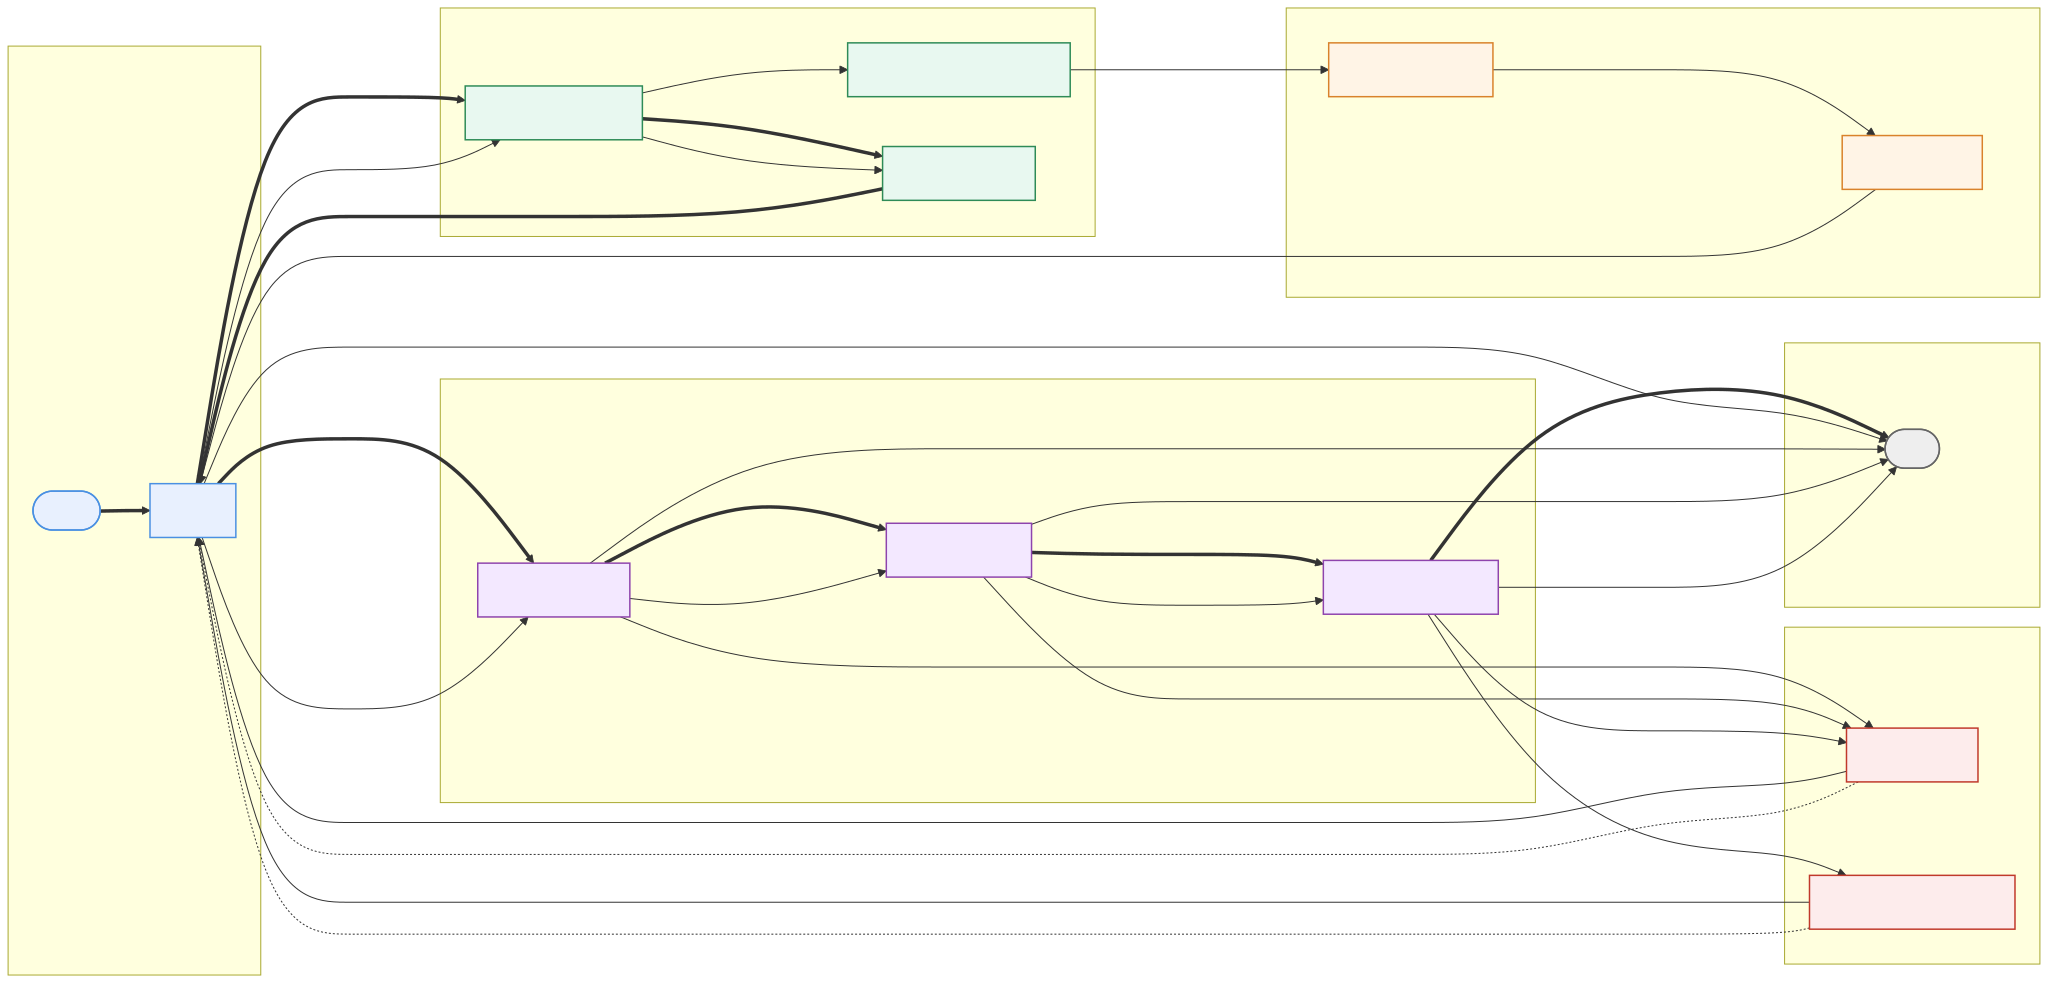

In [23]:
# =========================
# CONFIG
# =========================
SRC_FILE = "text2sql_langgraph.py"
OUT_DIR = "vis"


# =========================
# IMPORT
# =========================
import ast
import re
from pathlib import Path
from collections import defaultdict
from IPython.display import SVG, display
import requests


# =========================
# HELPERS
# =========================
def node_to_str(node):
    if isinstance(node, ast.Constant):
        return str(node.value)
    if isinstance(node, ast.Name):
        return node.id
    try:
        return ast.unparse(node)
    except Exception:
        return str(node)

def safe_label(s: str) -> str:
    return s.replace('"', "'")

def pretty_route_label(label: str) -> str:
    s = str(label)

    replacements = {
        "prepare_context": "prepare context",
        "safety_check": "go to safety check",
        "repair_sql": "repair",
        "semantic_check": "semantic check",
        "semantic_repair_sql": "semantic repair",
        "generate_sql": "generate",
        "rewrite_sql": "rewrite",
        "END": "end",
    }
    if s in replacements:
        return replacements[s]
    return s.replace("_", " ")

def classify_node(name: str) -> str:
    n = name.lower()
    if n in {"start", "end", "tick"}:
        return "control"
    if "rewrite" in n:
        return "rewrite"
    if "semantic" in n:
        return "semantic"
    if "repair" in n:
        return "repair"
    if "execute" in n or "safety" in n:
        return "execution"
    if "prepare" in n or "generate" in n or "classify" in n:
        return "generation"
    return "other"

def extract_return_key(node):
    if isinstance(node, ast.Return) and node.value is not None:
        if isinstance(node.value, ast.Constant):
            return str(node.value.value)
        if isinstance(node.value, ast.Name):
            return node.value.id
    return None


# =========================
# EXTRACT GRAPH
# =========================
class GraphExtractor(ast.NodeVisitor):
    def __init__(self):
        self.nodes = {}              # graph_node_name -> function_name
        self.edges = []              # (src, dst)
        self.cond_edges = []         # (src, route_fn, mapping_dict)
        self.route_fns = {}          # route_fn_name -> FunctionDef
        self.node_fns = {}           # function_name -> FunctionDef
        self.agent_state_fields = []

    def visit_ClassDef(self, node):
        if node.name == "AgentState":
            for stmt in node.body:
                if isinstance(stmt, ast.AnnAssign) and isinstance(stmt.target, ast.Name):
                    self.agent_state_fields.append(stmt.target.id)
        self.generic_visit(node)

    def visit_FunctionDef(self, node):
        if node.name.startswith("route_after_"):
            self.route_fns[node.name] = node
        if node.name.startswith("node_"):
            self.node_fns[node.name] = node
        self.generic_visit(node)

    def visit_Call(self, node):
        if isinstance(node.func, ast.Attribute):
            attr = node.func.attr

            if attr == "add_node" and len(node.args) >= 2:
                graph_node = node_to_str(node.args[0])
                fn_name = node_to_str(node.args[1])
                self.nodes[graph_node] = fn_name

            elif attr == "add_edge" and len(node.args) >= 2:
                src = node_to_str(node.args[0])
                dst = node_to_str(node.args[1])
                self.edges.append((src, dst))

            elif attr == "add_conditional_edges" and len(node.args) >= 3:
                src = node_to_str(node.args[0])
                route_fn = node_to_str(node.args[1])
                mapping = {}
                if isinstance(node.args[2], ast.Dict):
                    for k, v in zip(node.args[2].keys, node.args[2].values):
                        mapping[node_to_str(k)] = node_to_str(v)
                self.cond_edges.append((src, route_fn, mapping))

        self.generic_visit(node)


# =========================
# ROUTE ANALYSIS
# =========================
class RouteAnalyzer:
    def __init__(self, route_fn: ast.FunctionDef):
        self.route_fn = route_fn
        self.labels = defaultdict(list)   # return_key -> [label1, label2, ...]

    def analyze(self):
        self._walk(self.route_fn.body, active_cond=None)
        return dict(self.labels)

    def _cond_to_text(self, expr):
        try:
            s = ast.unparse(expr)
        except Exception:
            s = str(expr)

        s = s.replace("state.get(", "").replace(")", "")
        s = s.replace("cfg.", "")
        s = s.replace("state[", "").replace("]", "")
        s = s.replace('"', "").replace("'", "")
        s = s.replace("_", " ")
        s = re.sub(r"\s+", " ", s).strip()

        # 흔한 패턴 정리
        s = s.replace("error and Step limit exceeded in error", "step limit exceeded")
        s = s.replace("error", "error")
        s = s.replace("semantic error", "semantic error")
        s = s.replace("enable semantic check", "semantic check enabled")
        s = s.replace("attempts >= max repair attempts", "attempt limit reached")
        s = s.replace("not schema", "schema missing")

        return s

    def _merge_cond(self, a, b):
        if a and b:
            return f"{a} AND {b}"
        return a or b or "otherwise"

    def _walk(self, stmts, active_cond=None):
        for stmt in stmts:
            if isinstance(stmt, ast.If):
                cond = self._cond_to_text(stmt.test)
                self._walk(stmt.body, self._merge_cond(active_cond, cond))
                if stmt.orelse:
                    self._walk(stmt.orelse, self._merge_cond(active_cond, f"NOT ({cond})"))

            elif isinstance(stmt, ast.Return):
                key = extract_return_key(stmt)
                if key is not None:
                    self.labels[key].append(active_cond or "otherwise")


# =========================
# STATE READ/WRITE ANALYSIS
# =========================
class NodeStateAnalyzer(ast.NodeVisitor):
    def __init__(self, valid_fields):
        self.valid_fields = set(valid_fields)
        self.reads = set()
        self.writes = set()

    def visit_Call(self, node):
        # state.get("x")
        if (
            isinstance(node.func, ast.Attribute)
            and node.func.attr == "get"
            and isinstance(node.func.value, ast.Name)
            and node.func.value.id == "state"
            and len(node.args) >= 1
            and isinstance(node.args[0], ast.Constant)
            and isinstance(node.args[0].value, str)
        ):
            k = node.args[0].value
            if k in self.valid_fields:
                self.reads.add(k)
        self.generic_visit(node)

    def visit_Subscript(self, node):
        # state["x"]
        if (
            isinstance(node.value, ast.Name)
            and node.value.id == "state"
            and isinstance(node.slice, ast.Constant)
            and isinstance(node.slice.value, str)
        ):
            k = node.slice.value
            if k in self.valid_fields:
                self.reads.add(k)
        self.generic_visit(node)

    def visit_Return(self, node):
        # return {"sql": ..., "error": ...}
        if isinstance(node.value, ast.Dict):
            for k in node.value.keys:
                if isinstance(k, ast.Constant) and isinstance(k.value, str):
                    if k.value in self.valid_fields:
                        self.writes.add(k.value)
        self.generic_visit(node)


# =========================
# RENDER RAW MERMAID
# =========================
def render_raw_mermaid(ext: GraphExtractor, route_labels_map):
    lines = ["flowchart TD"]

    all_nodes = set(ext.nodes.keys())
    for s, d in ext.edges:
        all_nodes.add(s)
        all_nodes.add(d)
    for s, _, mp in ext.cond_edges:
        all_nodes.add(s)
        for d in mp.values():
            all_nodes.add(d)

    for n in sorted(all_nodes):
        if n == "START":
            lines.append(f'    {n}(["START"])')
        elif n == "END":
            lines.append(f'    {n}(["END"])')
        else:
            lines.append(f'    {n}["{safe_label(n)}"]')

    lines.append("")

    for s, d in ext.edges:
        lines.append(f"    {s} --> {d}")

    for s, route_fn, mp in ext.cond_edges:
        label_map = route_labels_map.get(route_fn, {})
        for ret_key, dst in mp.items():
            labels = label_map.get(ret_key, [pretty_route_label(ret_key)])
            label = " OR ".join(labels)
            label = safe_label(label)
            lines.append(f'    {s} -->|"{label}"| {dst}')

    return "\n".join(lines)


# =========================
# RENDER CLEAN MERMAID
# =========================
def render_clean_mermaid(ext: GraphExtractor, route_labels_map):
    all_nodes = set(ext.nodes.keys())
    for s, d in ext.edges:
        all_nodes.add(s)
        all_nodes.add(d)
    for s, _, mp in ext.cond_edges:
        all_nodes.add(s)
        for d in mp.values():
            all_nodes.add(d)

    # 보기 좋은 순서 고정
    preferred_order = [
        "START",
        "tick",
        "prepare_context",
        "classify_rewrite_intent",
        "generate_sql",
        "rewrite_reflect",
        "rewrite_sql",
        "safety_check",
        "execute_sql",
        "semantic_check",
        "repair_sql",
        "semantic_repair_sql",
        "END",
    ]

    present = [n for n in preferred_order if n in all_nodes]
    remaining = [n for n in sorted(all_nodes) if n not in present]

    groups = {
        "ENTRY": [],
        "GENERATION": [],
        "REWRITE": [],
        "EXECUTION": [],
        "RECOVERY": [],
        "EXIT": [],
        "OTHER": [],
    }

    for n in present + remaining:
        nl = n.lower()
        if n in {"START", "tick"}:
            groups["ENTRY"].append(n)
        elif n in {"END"}:
            groups["EXIT"].append(n)
        elif n in {"prepare_context", "classify_rewrite_intent", "generate_sql"}:
            groups["GENERATION"].append(n)
        elif n in {"rewrite_reflect", "rewrite_sql"}:
            groups["REWRITE"].append(n)
        elif n in {"safety_check", "execute_sql", "semantic_check"}:
            groups["EXECUTION"].append(n)
        elif n in {"repair_sql", "semantic_repair_sql"}:
            groups["RECOVERY"].append(n)
        else:
            groups["OTHER"].append(n)

    lines = ["flowchart LR"]

    # 스타일
    lines += [
        "    classDef entry fill:#e8f0fe,stroke:#4a90e2,stroke-width:1.5px;",
        "    classDef gen fill:#e8f8f0,stroke:#2e8b57,stroke-width:1.5px;",
        "    classDef rewrite fill:#fff4e6,stroke:#d9822b,stroke-width:1.5px;",
        "    classDef exec fill:#f3e8ff,stroke:#8e44ad,stroke-width:1.5px;",
        "    classDef recovery fill:#fdecec,stroke:#c0392b,stroke-width:1.5px;",
        "    classDef exit fill:#eeeeee,stroke:#666666,stroke-width:1.5px;",
        "",
    ]

    def add_subgraph(title, nodes, cls):
        if not nodes:
            return
        lines.append(f"    subgraph {title}")
        for n in nodes:
            if n == "START":
                lines.append(f'        {n}(["START"])')
            elif n == "END":
                lines.append(f'        {n}(["END"])')
            else:
                lines.append(f'        {n}["{safe_label(n)}"]')
        lines.append("    end")
        for n in nodes:
            lines.append(f"    class {n} {cls};")
        lines.append("")

    add_subgraph("ENTRY", groups["ENTRY"], "entry")
    add_subgraph("GENERATION", groups["GENERATION"], "gen")
    add_subgraph("REWRITE", groups["REWRITE"], "rewrite")
    add_subgraph("EXECUTION", groups["EXECUTION"], "exec")
    add_subgraph("RECOVERY", groups["RECOVERY"], "recovery")
    add_subgraph("OTHER", groups["OTHER"], "gen")
    add_subgraph("EXIT", groups["EXIT"], "exit")

    # 메인 백본 우선
    backbone = [
        ("START", "tick"),
        ("tick", "prepare_context"),
        ("prepare_context", "generate_sql"),
        ("generate_sql", "tick"),
        ("tick", "safety_check"),
        ("safety_check", "execute_sql"),
        ("execute_sql", "semantic_check"),
        ("semantic_check", "END"),
    ]
    backbone_set = set(backbone)

    for s, d in backbone:
        if s in all_nodes and d in all_nodes:
            lines.append(f"    {s} ==> {d}")
    lines.append("")

    # 일반 edge
    for s, d in ext.edges:
        if (s, d) in backbone_set:
            continue
        if s in all_nodes and d in all_nodes:
            lines.append(f"    {s} --> {d}")

    # 조건부 edge
    for s, route_fn, mp in ext.cond_edges:
        label_map = route_labels_map.get(route_fn, {})
        for ret_key, dst in mp.items():
            labels = label_map.get(ret_key, [pretty_route_label(ret_key)])
            label = " OR ".join(labels)
            label = safe_label(label)

            # 라벨 너무 길면 줄이기
            label = (
                label.replace("otherwise", "default")
                     .replace("semantic check enabled", "semantic on")
                     .replace("attempt limit reached", "attempts exhausted")
                     .replace("schema missing", "no schema")
            )

            if s in all_nodes and dst in all_nodes:
                lines.append(f'    {s} -->|"{label}"| {dst}')

    # recovery loop 강조
    if "repair_sql" in all_nodes and "tick" in all_nodes:
        lines.append("    repair_sql -. retry .-> tick")
    if "semantic_repair_sql" in all_nodes and "tick" in all_nodes:
        lines.append("    semantic_repair_sql -. retry .-> tick")

    return "\n".join(lines)


# =========================
# RENDER STATE MAP
# =========================
def render_state_field_map(ext: GraphExtractor):
    lines = ["# State Field Map", "", "## AgentState fields", ""]
    for f in ext.agent_state_fields:
        lines.append(f"- `{f}`")

    lines += ["", "## Node read/write map", "", "| node | function | reads | writes |", "|---|---|---|---|"]

    for node_name, fn_name in sorted(ext.nodes.items()):
        fn = ext.node_fns.get(fn_name)
        if fn is None:
            reads = ""
            writes = ""
        else:
            analyzer = NodeStateAnalyzer(ext.agent_state_fields)
            analyzer.visit(fn)
            reads = ", ".join(f"`{x}`" for x in sorted(analyzer.reads))
            writes = ", ".join(f"`{x}`" for x in sorted(analyzer.writes))
        lines.append(f"| `{node_name}` | `{fn_name}` | {reads} | {writes} |")

    return "\n".join(lines)


# =========================
# RENDER ROUTE DEBUG
# =========================
def render_route_debug(route_labels_map):
    lines = ["# Route Debug", ""]
    for route_fn, mp in sorted(route_labels_map.items()):
        lines.append(f"## `{route_fn}`")
        lines.append("")
        for ret_key, labels in mp.items():
            lines.append(f"- `{ret_key}`")
            for lb in labels:
                lines.append(f"  - {lb}")
        lines.append("")
    return "\n".join(lines)


# =========================
# KROKI RENDER
# =========================
def kroki_render_mermaid_to_svg(mmd_text: str, out_path: Path):
    resp = requests.post(
        "https://kroki.io/mermaid/svg",
        data=mmd_text.encode("utf-8"),
        headers={"Content-Type": "text/plain"},
        timeout=60,
    )
    if resp.status_code != 200:
        raise RuntimeError(f"Kroki render failed: {resp.status_code}\n{resp.text[:1000]}")
    out_path.write_bytes(resp.content)


# =========================
# RUN
# =========================
src_path = Path(SRC_FILE)
out_dir = Path(OUT_DIR)
out_dir.mkdir(exist_ok=True)

code = src_path.read_text(encoding="utf-8")
tree = ast.parse(code)

ext = GraphExtractor()
ext.visit(tree)

route_labels_map = {}
for route_fn_name, fn in ext.route_fns.items():
    route_labels_map[route_fn_name] = RouteAnalyzer(fn).analyze()

workflow_raw = render_raw_mermaid(ext, route_labels_map)
workflow_clean = render_clean_mermaid(ext, route_labels_map)
state_md = render_state_field_map(ext)
route_md = render_route_debug(route_labels_map)

(out_dir / "workflow_raw.mmd").write_text(workflow_raw, encoding="utf-8")
(out_dir / "workflow_clean.mmd").write_text(workflow_clean, encoding="utf-8")
(out_dir / "state_field_map.md").write_text(state_md, encoding="utf-8")
(out_dir / "routes_debug.md").write_text(route_md, encoding="utf-8")

kroki_render_mermaid_to_svg(workflow_clean, out_dir / "workflow_clean.svg")

print("생성 완료:")
print("-", out_dir / "workflow_raw.mmd")
print("-", out_dir / "workflow_clean.mmd")
print("-", out_dir / "state_field_map.md")
print("-", out_dir / "routes_debug.md")
print("-", out_dir / "workflow_clean.svg")

display(SVG(filename=str(out_dir / "workflow_clean.svg")))